In [2]:
!pip install scikeras

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
Number of classes:  10
Classes: [0 1 2 3 4 5 6 7 8 9]


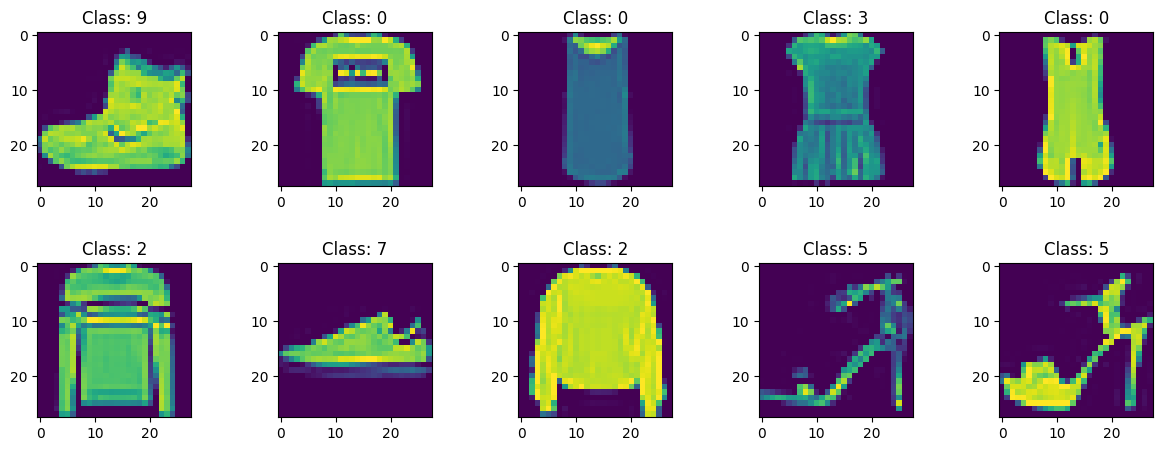

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8136 - loss: 0.5278 - val_accuracy: 0.8410 - val_loss: 0.4361
Epoch 2/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8606 - loss: 0.3890 - val_accuracy: 0.8633 - val_loss: 0.3715
Epoch 3/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8730 - loss: 0.3471 - val_accuracy: 0.8625 - val_loss: 0.3803
Epoch 4/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8828 - loss: 0.3214 - val_accuracy: 0.8733 - val_loss: 0.3460
Epoch 5/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8898 - loss: 0.3011 - val_accuracy: 0.8800 - val_loss: 0.3397
Epoch 6/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8942 - loss: 0.2855 - val_accuracy: 0.8767 - val_loss: 0.3495
Epoch 7/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8989 - loss: 0.2738 - val_accuracy: 0.8750 - val_loss: 0.3468
Epoch 8/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9024 - loss: 0.2613 -

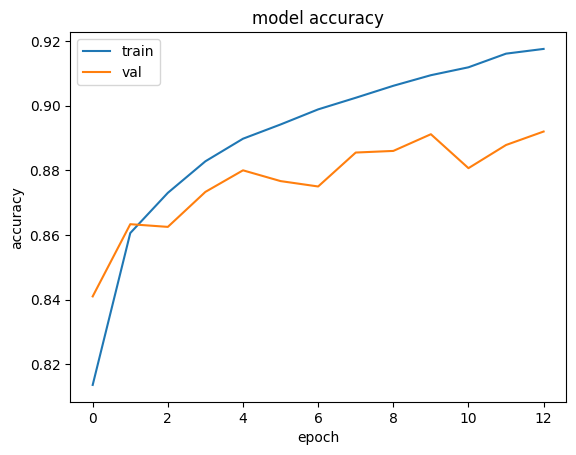

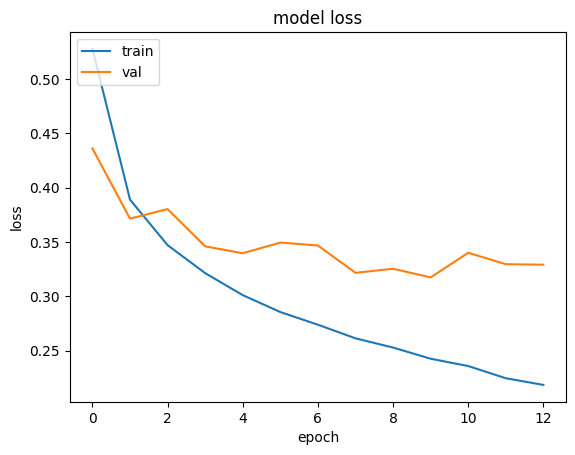

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


In [8]:
# 3.1. Nạp thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping

# 3.2. Đọc tập dữ liệu FASHION MNIST
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# 3.3. Xử lý dữ liệu
# reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# feature scaling
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

# 3.4. Trực quan hóa dữ liệu
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# 3.5. Xây dựng mô hình học ANN
fashion_model = Sequential()
# add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=128,
                        kernel_initializer='uniform', activation='relu'))
# add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform',
                        activation='softmax'))
#tracking val_loss to find the most optimized value
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)

# compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
fashion_model.summary()

# 3.6. Huấn luyện ANN model
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1,
                              epochs=35, verbose=1,callbacks=[early_stop])

# 3.7. Đánh giá ANN model
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 3.8. Dự báo ảnh mới
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3318 - loss: 1.8539 - val_accuracy: 0.3876 - val_loss: 1.7318
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3945 - loss: 1.6866 - val_accuracy: 0.3842 - val_loss: 1.6882
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4198 - loss: 1.6197 - val_accuracy: 0.4374 - val_loss: 1.6169
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4403 - loss: 1.5767 - val_accuracy: 0.4354 - val_loss: 1.5981
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4483 - loss: 1.5508 - val_accuracy: 0.4282 - val_loss: 1.6344
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4567 - loss: 1.5231 - val_accuracy: 0.4370 - val_loss: 1.5892
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4656 - loss: 1.5011 - val_accuracy: 0.4618 - val_loss: 1.5191
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4755 -

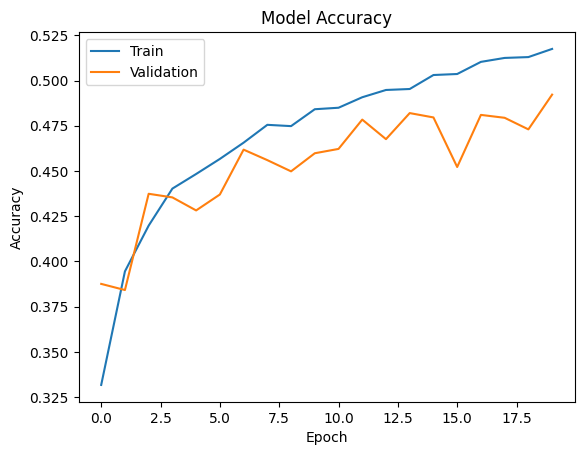

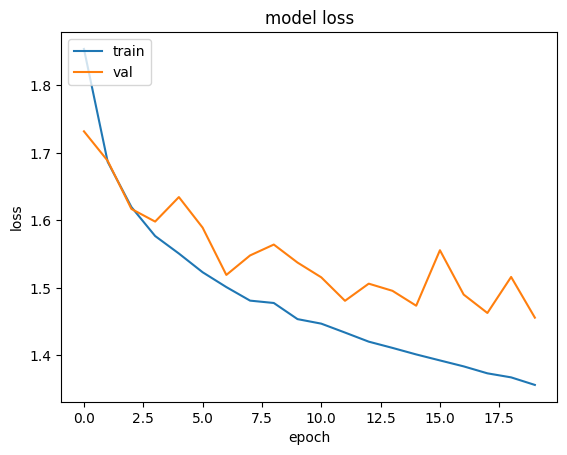

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Nhãn dự đoán: 6 | Nhãn thực tế: 3


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.reshape(X_train.shape[0], 3072)
X_test = X_test.reshape(X_test.shape[0], 3072)

minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

model = Sequential()
model.add(Dense(input_dim=3072, units=256, kernel_initializer='uniform',
                activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20,
                      verbose=1)

plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

sample_img = X_test[0:1]
prediction = np.argmax(model.predict(sample_img))
print(f"Nhãn dự đoán: {prediction} | Nhãn thực tế: {y_test[0][0]}")